# BayesBench: Bayesian Early Stopping for LLM Benchmarking

This notebook is a self-contained, runnable companion to the [BayesBench demo](https://github.com/rymarinelli/bayesbench-demo) Streamlit app.

**The idea:** when comparing two models on a benchmark, you don't need to run the full dataset to know who's winning. After each example, update a Bayesian posterior over "P(Model A beats Model B)" and stop as soon as that posterior is confident enough. This can cut evaluation cost dramatically when one model is clearly better (or clearly worse).

In this notebook we:
1. Load a small subset of [BoolQ](https://huggingface.co/datasets/google/boolq) (yes/no reading comprehension).
2. Compare a real local LLM ([SmolLM2-135M-Instruct](https://huggingface.co/HuggingFaceTB/SmolLM2-135M-Instruct)) against a simple majority-class baseline.
3. Run a Beta-Bernoulli Bayesian sequential test, updating after every example.
4. Stop early once `P(A > B) >= confidence` (or vice versa), and plot how the posterior evolved.

Everything runs on CPU, no API keys required.

In [1]:
# Uncomment if running in a fresh environment (e.g. Colab):
# %pip install -q datasets transformers accelerate numpy matplotlib
# %pip install -q torch --index-url https://download.pytorch.org/whl/cpu

In [2]:
import re

import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import pipeline

SEED = 42
SUBSET_SIZE = 40
CONFIDENCE = 0.90       # stop as soon as P(A>B) or P(B>A) reaches this
CREDIBILITY = 0.95      # width of the reported credible interval
MAX_NEW_TOKENS = 8      # we only need a Yes/No answer

## 1. Load a BoolQ subset

In [3]:
def load_boolq_subset(subset_size: int, seed: int, split: str = "validation"):
    ds = load_dataset("google/boolq", split=split)
    ds = ds.shuffle(seed=seed).select(range(min(subset_size, len(ds))))
    return [
        {"question": row["question"], "context": row["passage"], "answer": bool(row["answer"])}
        for row in ds
    ]


dataset = load_boolq_subset(SUBSET_SIZE, SEED)
print(f"Loaded {len(dataset)} BoolQ examples")
dataset[0]

Loaded 40 BoolQ examples


{'question': 'is garrison from the ranch a real place',
 'context': 'The Ranch is an American comedy web television series starring Ashton Kutcher, Danny Masterson, Debra Winger, Elisha Cuthbert, and Sam Elliott that debuted in 2016 on Netflix. The show takes place on the fictional Iron River Ranch in the fictitious small town of Garrison, Colorado; detailing the life of the Bennetts, a dysfunctional family consisting of two brothers, their rancher father, and his divorced wife and local bar owner. While the opening sequence shows scenes from Norwood and Ouray, Colorado and surrounding Ouray and San Miguel Counties, The Ranch is filmed on a sound stage in front of a live audience in Burbank, California. Each season consists of 20 episodes broken up into two parts, each containing 10 episodes.',
 'answer': False}

## 2. Define the two models

- **Model A** — `SmolLM2-135M-Instruct`, a real (tiny) instruction-tuned LLM run locally via `transformers`.
- **Model B** — `AlwaysNo`, a deliberately weak baseline that always answers "No" (BoolQ is skewed toward "Yes", so this scores ~38%). We use `AlwaysNo` rather than `AlwaysYes` because the tiny 135M model turns out to answer "Yes" on almost every example too — pairing it against `AlwaysNo` gives a clear, decisive separation that actually demonstrates early stopping.

In [4]:
_pipe = pipeline("text-generation", model="HuggingFaceTB/SmolLM2-135M-Instruct", device="cpu")


def smollm2_model(example: dict) -> str:
    prompt = (
        "Answer the question with only Yes or No.\n\n"
        f"Question: {example['question']}\n\nPassage: {example['context']}"
    )
    messages = [
        {"role": "system", "content": "You are a concise, helpful assistant."},
        {"role": "user", "content": prompt},
    ]
    result = _pipe(messages, max_new_tokens=MAX_NEW_TOKENS, do_sample=False)
    generated = result[0]["generated_text"]
    if isinstance(generated, list):
        for msg in reversed(generated):
            if isinstance(msg, dict) and msg.get("role") == "assistant":
                return msg.get("content", "").strip()
    return str(generated).strip()


def always_no_model(example: dict) -> str:
    return "No"


MODEL_A_NAME, model_a_fn = "SmolLM2-135M-Instruct", smollm2_model
MODEL_B_NAME, model_b_fn = "AlwaysNo (deliberately weak baseline)", always_no_model

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

## 3. Scoring

A response scores 1.0 if its first yes/no word matches the gold label, else 0.0.

In [5]:
TRUE_WORDS = {"yes", "true", "correct"}
FALSE_WORDS = {"no", "false", "incorrect"}


def parse_yes_no(text: str):
    words = re.findall(r"[a-z]+", text.strip().lower())
    if not words:
        return None
    if words[0] in TRUE_WORDS:
        return True
    if words[0] in FALSE_WORDS:
        return False
    if "yes" in words:
        return True
    if "no" in words:
        return False
    return None


def boolq_score(example: dict, response: str) -> float:
    pred = parse_yes_no(response)
    if pred is None:
        return 0.0
    return 1.0 if pred == example["answer"] else 0.0

## 4. Bayesian sequential test

Each model's score is treated as a Bernoulli trial. We keep a `Beta(alpha, beta)` posterior over each model's true accuracy, starting from an uninformative `Beta(1, 1)` prior. After every example we update both posteriors and Monte Carlo-estimate `P(A > B)` by sampling from each. We stop as soon as that probability (or its complement) crosses `CONFIDENCE`.

In [6]:
def bayesian_sequential_test(scores_a, scores_b, confidence, credibility, mc_samples=10_000, seed=0):
    rng = np.random.default_rng(seed)
    alpha_a = beta_a = 1.0
    alpha_b = beta_b = 1.0
    trace = []
    winner = None
    stopped_at = len(scores_a)

    for i, (sa, sb) in enumerate(zip(scores_a, scores_b)):
        alpha_a += sa; beta_a += 1 - sa
        alpha_b += sb; beta_b += 1 - sb

        samp_a = rng.beta(alpha_a, beta_a, mc_samples)
        samp_b = rng.beta(alpha_b, beta_b, mc_samples)
        p_a_beats_b = float((samp_a > samp_b).mean())

        trace.append({
            "sample": i + 1,
            "p_a_beats_b": p_a_beats_b,
            "mean_a": alpha_a / (alpha_a + beta_a),
            "mean_b": alpha_b / (alpha_b + beta_b),
        })

        if winner is None:
            if p_a_beats_b >= confidence:
                winner, stopped_at = "A", i + 1
                break
            if p_a_beats_b <= 1 - confidence:
                winner, stopped_at = "B", i + 1
                break

    samp_a = rng.beta(alpha_a, beta_a, mc_samples)
    samp_b = rng.beta(alpha_b, beta_b, mc_samples)
    tail = (1 - credibility) / 2 * 100

    result = {
        "winner": winner,
        "p_a_beats_b": float((samp_a > samp_b).mean()),
        "mean_a": alpha_a / (alpha_a + beta_a),
        "mean_b": alpha_b / (alpha_b + beta_b),
        "ci_a": (float(np.percentile(samp_a, tail)), float(np.percentile(samp_a, 100 - tail))),
        "ci_b": (float(np.percentile(samp_b, tail)), float(np.percentile(samp_b, 100 - tail))),
        "problems_tested": stopped_at,
        "total_problems": len(scores_a),
        "efficiency": 1 - stopped_at / len(scores_a) if len(scores_a) else 0.0,
    }
    return result, trace

## 5. Run the comparison

We evaluate example-by-example so the posterior can be updated live. In a real early-stopping setup you'd break out of this loop the moment the Bayesian test decides — here we score the full subset first (so the notebook always has data to plot) and then run the sequential test over the collected scores, which is equivalent to stopping the moment `problems_tested` is reached.

In [7]:
scores_a, scores_b = [], []
for i, ex in enumerate(dataset):
    resp_a = model_a_fn(ex)
    resp_b = model_b_fn(ex)
    scores_a.append(boolq_score(ex, resp_a))
    scores_b.append(boolq_score(ex, resp_b))
    if (i + 1) % 10 == 0 or i == len(dataset) - 1:
        print(f"[{i + 1}/{len(dataset)}] running accuracy — {MODEL_A_NAME}: {np.mean(scores_a):.2f}  |  {MODEL_B_NAME}: {np.mean(scores_b):.2f}")

result, trace = bayesian_sequential_test(scores_a, scores_b, CONFIDENCE, CREDIBILITY)
result

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[transformers] Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[transformers] Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=8) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[40/40] running accuracy — SmolLM2-135M-Instruct: 0.57  |  AlwaysNo (deliberately weak baseline): 0.42


{'winner': 'A',
 'p_a_beats_b': 0.9589,
 'mean_a': 0.7142857142857143,
 'mean_b': 0.2857142857142857,
 'ci_a': (0.35330089791810126, 0.955616857225659),
 'ci_b': (0.04078649897488167, 0.6499405360307362),
 'problems_tested': 5,
 'total_problems': 40,
 'efficiency': 0.875}

## 6. Results

In [8]:
winner_name = MODEL_A_NAME if result["winner"] == "A" else MODEL_B_NAME if result["winner"] == "B" else "Inconclusive"
print(f"Winner: {winner_name}")
print(f"P({MODEL_A_NAME} > {MODEL_B_NAME}) = {result['p_a_beats_b']:.3f}")
print(f"Problems tested: {result['problems_tested']}/{result['total_problems']}  "
      f"({result['efficiency']:.1%} of the dataset saved)")
print(f"{MODEL_A_NAME}: mean={result['mean_a']:.3f}  {int(CREDIBILITY*100)}% CI={result['ci_a']}")
print(f"{MODEL_B_NAME}: mean={result['mean_b']:.3f}  {int(CREDIBILITY*100)}% CI={result['ci_b']}")

Winner: SmolLM2-135M-Instruct
P(SmolLM2-135M-Instruct > AlwaysNo (deliberately weak baseline)) = 0.959
Problems tested: 5/40  (87.5% of the dataset saved)
SmolLM2-135M-Instruct: mean=0.714  95% CI=(0.35330089791810126, 0.955616857225659)
AlwaysNo (deliberately weak baseline): mean=0.286  95% CI=(0.04078649897488167, 0.6499405360307362)


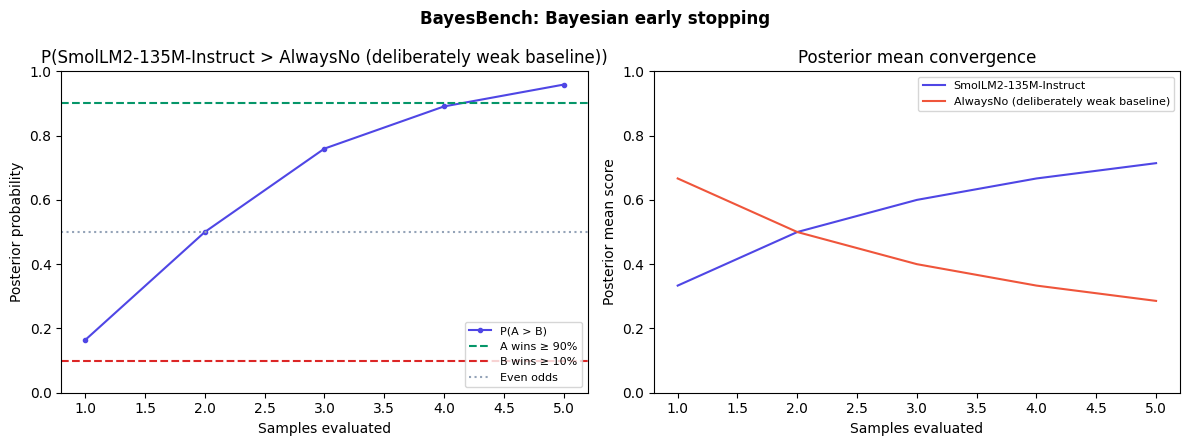

In [9]:
samples = [t["sample"] for t in trace]
p_curve = [t["p_a_beats_b"] for t in trace]
mean_a_curve = [t["mean_a"] for t in trace]
mean_b_curve = [t["mean_b"] for t in trace]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(samples, p_curve, color="#4F46E5", marker="o", markersize=3, label="P(A > B)")
ax.axhline(CONFIDENCE, color="#059669", linestyle="--", label=f"A wins \u2265 {CONFIDENCE:.0%}")
ax.axhline(1 - CONFIDENCE, color="#DC2626", linestyle="--", label=f"B wins \u2265 {1 - CONFIDENCE:.0%}")
ax.axhline(0.5, color="#94A3B8", linestyle=":", label="Even odds")
ax.set_ylim(0, 1)
ax.set_xlabel("Samples evaluated")
ax.set_ylabel("Posterior probability")
ax.set_title(f"P({MODEL_A_NAME} > {MODEL_B_NAME})")
ax.legend(fontsize=8, loc="lower right")

ax = axes[1]
ax.plot(samples, mean_a_curve, color="#4F46E5", label=MODEL_A_NAME)
ax.plot(samples, mean_b_curve, color="#EF553B", label=MODEL_B_NAME)
ax.set_ylim(0, 1)
ax.set_xlabel("Samples evaluated")
ax.set_ylabel("Posterior mean score")
ax.set_title("Posterior mean convergence")
ax.legend(fontsize=8)

fig.suptitle("BayesBench: Bayesian early stopping", fontweight="bold")
fig.tight_layout()
plt.show()

## Next steps

- Try a closer matchup (e.g. `SmolLM2-135M-Instruct` vs `SmolLM2-360M-Instruct`) to see how much longer the test runs before the posteriors separate.
- Lower `CONFIDENCE` to stop earlier (less certain) or raise it to demand more evidence.
- Swap in your own scoring function or dataset — the sequential test only needs a `[0, 1]`-valued score per example.
- For the full interactive experience (multi-task suites, model ranking, agent/tool-use benchmarks, custom HF datasets), see the [Streamlit demo](https://github.com/rymarinelli/bayesbench-demo).
- The underlying package is [`bayesbench`](https://github.com/rymarinelli/bayesbench), which this notebook's `bayesian_sequential_test` mirrors in miniature.